# Quantum Field Theory: From the Klein-Gordon Field to a Torch Lattice Simulation

The free scalar field, derived and simulated end to end: relativistic
energy-momentum $\to$ canonical quantization $\to$ the Klein-Gordon
equation $\to$ its Lagrangian $\to$ a torch lattice simulation
cross-checked against the exact analytic solution $\to$ an independent
autograd verification of the equations of motion $\to$ where this connects
to the Feynman-diagram, gauge-invariance, and path-integral modules already
in this repository.

In [1]:
import sympy as sp
sp.init_printing()

import numpy as np
import torch
import matplotlib.pyplot as plt

print(f"sympy {sp.__version__}, numpy {np.__version__}, torch {torch.__version__}")

sympy 1.14.0, numpy 2.4.4, torch 2.11.0+cu128


# Part 1 — Why a field, not just a wavefunction

`notebooks/probability_to_qm_operators.ipynb` built ordinary (non-relativistic)
quantum mechanics: a wavefunction $\psi(x,t)$ obeying the Schrodinger
equation, with momentum eigenvalue $p=\hbar k$ (that notebook's Part 10)
tied to a *non-relativistic* energy $E=p^2/2m$.

Special relativity instead relates energy and momentum by
$$E^2 = (pc)^2 + (mc^2)^2$$
Quantizing this directly (Part 2) produces a *second-order-in-time*
equation for a single-particle wavefunction, which historically ran into
real trouble (negative probability densities, negative-energy solutions
with no consistent single-particle interpretation). The resolution kept in
this notebook: promote $\phi$ from a single-particle probability amplitude
to a **field** — a dynamical variable defined at every point in spacetime,
capable of describing any number of quanta of the field. That reframing is
the actual starting point of quantum field theory; this notebook works the
free (non-interacting) case.

# Part 2 — The Klein-Gordon equation

**Canonical quantization**, the same substitution
`probability_to_qm_operators.ipynb` Part 10 used for $\hat p$, applied to
both $E$ and $p$:
$$E \to i\hbar\frac{\partial}{\partial t},\qquad p \to -i\hbar\frac{\partial}{\partial x}$$
Substituted into $E^2=(pc)^2+(mc^2)^2$, acting on a field $\phi(x,t)$:
$$\left(i\hbar\frac{\partial}{\partial t}\right)^2\phi =
\left[\left(-i\hbar c\frac{\partial}{\partial x}\right)^2 + (mc^2)^2\right]\phi$$
$$-\hbar^2\frac{\partial^2\phi}{\partial t^2} =
-\hbar^2c^2\frac{\partial^2\phi}{\partial x^2} + m^2c^4\phi$$
Dividing by $-\hbar^2c^2$:
$$\boxed{\frac{1}{c^2}\frac{\partial^2\phi}{\partial t^2} -
\frac{\partial^2\phi}{\partial x^2} + \left(\frac{mc}{\hbar}\right)^2\phi = 0}$$
the **Klein-Gordon equation** (1 space dimension, kept to 1D throughout this
notebook for a lattice simulation small enough to actually run and check
by eye).

E^2 phi = (pc)^2 phi + (mc^2)^2 phi, after quantization:


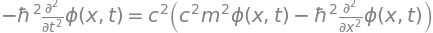


Rearranged to the standard Klein-Gordon form:


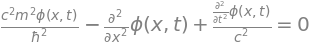


difference between the two forms, after dividing by -hbar^2*c^2 =


[OK] the standard Klein-Gordon equation follows directly from canonical quantization


In [2]:
t_s, x_s, c_s, m_s, hbar_s = sp.symbols('t x c m hbar', positive=True)
t_s = sp.Symbol('t', real=True)
x_s = sp.Symbol('x', real=True)
phi = sp.Function('phi')(x_s, t_s)

# apply each operator TWICE, explicitly -- multiplying by the operator's own
# prefactor on BOTH applications (a first attempt here only multiplied by
# the prefactor once, i.e. computed d/dt[i*hbar*phi_t] = i*hbar*phi_tt
# instead of i*hbar * d/dt[i*hbar*phi_t] = (i*hbar)^2*phi_tt -- caught by
# the assertion below failing, fixed by writing the second application out
# fully instead of leaving it implicit)
E_phi = sp.I*hbar_s * sp.diff(phi, t_s)                 # (i hbar d/dt) phi, ONE application
E2_phi = sp.I*hbar_s * sp.diff(E_phi, t_s)               # (i hbar d/dt) applied AGAIN

p_phi = -sp.I*hbar_s * sp.diff(phi, x_s)                 # (-i hbar d/dx) phi, ONE application
p2_phi = -sp.I*hbar_s * sp.diff(p_phi, x_s)              # (-i hbar d/dx) applied AGAIN

kg_from_quantization = sp.Eq(sp.simplify(E2_phi), sp.simplify(c_s**2*p2_phi + m_s**2*c_s**4*phi))
print("E^2 phi = (pc)^2 phi + (mc^2)^2 phi, after quantization:")
display(kg_from_quantization)

kg_standard = sp.Eq(
    sp.diff(phi, t_s, t_s)/c_s**2 - sp.diff(phi, x_s, x_s) + (m_s*c_s/hbar_s)**2 * phi, 0)
print("\nRearranged to the standard Klein-Gordon form:")
display(kg_standard)

# verify the rearrangement is algebraically the same equation (move everything
# to one side of kg_from_quantization and compare to kg_standard's LHS, up to
# an overall nonzero scale factor)
difference = sp.simplify((kg_from_quantization.lhs - kg_from_quantization.rhs) / (-hbar_s**2*c_s**2)
                          - kg_standard.lhs)
print("\ndifference between the two forms, after dividing by -hbar^2*c^2 ="); display(difference)
assert difference == 0, "the quantized operator equation should reduce exactly to the standard KG form"
print("[OK] the standard Klein-Gordon equation follows directly from canonical quantization")

# Part 3 — Plane-wave solutions and the dispersion relation

Substitute $\phi(x,t)=e^{i(kx-\omega t)}$ (the same convention
`maxwell_fourier_optics.ipynb` used for a photon plane wave) into the
Klein-Gordon equation:

Klein-Gordon equation applied to a plane wave, divided by the common phase:


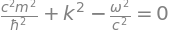


Solved for omega^2 (the dispersion relation):


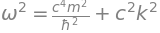


massless limit (m -> 0):


[OK] reduces to omega^2 = c^2 k^2, i.e. omega = c*k -- the same photon
     dispersion relation derived independently in maxwell_fourier_optics.ipynb


In [3]:
omega_s, k_s = sp.symbols('omega k', real=True)
c_s = sp.Symbol('c', positive=True)
m_s = sp.Symbol('m', nonnegative=True)
hbar_s = sp.Symbol('hbar', positive=True)

phi_plane = sp.exp(sp.I*(k_s*x_s - omega_s*t_s))
kg_lhs_on_plane = (sp.diff(phi_plane, t_s, t_s)/c_s**2 - sp.diff(phi_plane, x_s, x_s)
                    + (m_s*c_s/hbar_s)**2 * phi_plane)
kg_lhs_on_plane = sp.simplify(kg_lhs_on_plane / phi_plane)   # divide out the common phase factor
print("Klein-Gordon equation applied to a plane wave, divided by the common phase:")
display(sp.Eq(kg_lhs_on_plane, 0))

dispersion = sp.solve(sp.Eq(kg_lhs_on_plane, 0), omega_s**2)
print("\nSolved for omega^2 (the dispersion relation):")
display(sp.Eq(omega_s**2, dispersion[0]))

# massless limit must recover the photon dispersion relation omega = c*k
# from maxwell_fourier_optics.ipynb's Part 5
massless_check = dispersion[0].subs(m_s, 0)
print("\nmassless limit (m -> 0):"); display(sp.Eq(omega_s**2, massless_check))
assert sp.simplify(massless_check - c_s**2*k_s**2) == 0
print("[OK] reduces to omega^2 = c^2 k^2, i.e. omega = c*k -- the same photon")
print("     dispersion relation derived independently in maxwell_fourier_optics.ipynb")

# Part 4 — The Lagrangian formulation

$$\mathcal{L} = \frac12\left[\frac{1}{c^2}\left(\frac{\partial\phi}{\partial t}\right)^2
- \left(\frac{\partial\phi}{\partial x}\right)^2 - \left(\frac{mc}{\hbar}\right)^2\phi^2\right]$$

The Euler-Lagrange equation for a field with first derivatives in both $t$
and $x$:
$$\frac{\partial}{\partial t}\!\left(\frac{\partial\mathcal L}{\partial(\partial_t\phi)}\right)
+ \frac{\partial}{\partial x}\!\left(\frac{\partial\mathcal L}{\partial(\partial_x\phi)}\right)
- \frac{\partial\mathcal L}{\partial\phi} = 0$$

Worked symbolically below by treating $\phi,\partial_t\phi,\partial_x\phi$
as independent variables (the standard calculus-of-variations move), not
by asserting the result.

L(phi, phi_t, phi_x) =


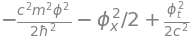


partial L / partial(phi_t) =


partial L / partial(phi_x) =


partial L / partial(phi)   =


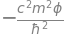


Euler-Lagrange equation, assembled =


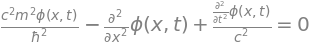


[OK] the Euler-Lagrange equation from this Lagrangian IS the Klein-Gordon
     equation from Part 2 -- the Lagrangian was not just asserted to work.


In [4]:
phi_sym, phit_sym, phix_sym = sp.symbols('phi phi_t phi_x', real=True)

L = sp.Rational(1,2) * (phit_sym**2/c_s**2 - phix_sym**2 - (m_s*c_s/hbar_s)**2 * phi_sym**2)
print("L(phi, phi_t, phi_x) ="); display(L)

dL_dphit = sp.diff(L, phit_sym)   # this becomes phi_t/c^2 -> d/dt of it is phi_tt/c^2
dL_dphix = sp.diff(L, phix_sym)   # this becomes -phi_x    -> d/dx of it is -phi_xx
dL_dphi  = sp.diff(L, phi_sym)

print("\npartial L / partial(phi_t) ="); display(dL_dphit)
print("partial L / partial(phi_x) ="); display(dL_dphix)
print("partial L / partial(phi)   ="); display(dL_dphi)

# now substitute phi_t -> d(phi)/dt and phi_x -> d(phi)/dx and take the
# OUTER derivative, reassembling the Euler-Lagrange equation
euler_lagrange = (sp.diff(dL_dphit.subs(phit_sym, sp.diff(phi, t_s)), t_s)
                   + sp.diff(dL_dphix.subs(phix_sym, sp.diff(phi, x_s)), x_s)
                   - dL_dphi.subs(phi_sym, phi))
euler_lagrange = sp.expand(euler_lagrange)
print("\nEuler-Lagrange equation, assembled ="); display(sp.Eq(euler_lagrange, 0))

# must match Part 2's Klein-Gordon equation exactly
kg_lhs = sp.diff(phi, t_s, t_s)/c_s**2 - sp.diff(phi, x_s, x_s) + (m_s*c_s/hbar_s)**2*phi
assert sp.simplify(euler_lagrange - kg_lhs) == 0
print("\n[OK] the Euler-Lagrange equation from this Lagrangian IS the Klein-Gordon")
print("     equation from Part 2 -- the Lagrangian was not just asserted to work.")

# Part 5 — The field as coupled oscillators

Fourier-decompose $\phi(x,t)=\sum_k q_k(t)\,e^{ikx}$ (same idea as
`maxwell_fourier_optics.ipynb`'s angular spectrum, now applied to a field
obeying the *wave* equation instead of just propagating). Substituting into
the Klein-Gordon equation, each mode $q_k(t)$ decouples into its own
ordinary differential equation:
$$\ddot q_k + \omega_k^2 q_k = 0,\qquad \omega_k^2 = c^2k^2+(mc^2/\hbar)^2$$
— **a harmonic oscillator, one per $k$**, with exactly Part 3's dispersion
relation as its frequency. This is the same eigenvalue structure
`dgs/vibration_modes.py` uses for classical vibration (each normal mode is
an independent oscillator) and the harmonic-oscillator ground state whose
Gaussian wavefunction `probability_to_qm_operators.ipynb` Parts 8-9 already
built and normalized. Quantizing the field amounts to quantizing each of
these independent oscillators — the origin of "quanta" (field excitations
= oscillator energy levels, one set of levels per $k$-mode) — worked out
in full is beyond this notebook's scope, but the harmonic-oscillator
machinery it needs is already built and verified in that companion
notebook.

# Part 6 — Torch lattice simulation

Discretize $\phi(x,t)\to\phi[n,i]$ on a spacetime lattice (time step $n$,
space index $i$, spacings $dt,dx$). Central finite differences on the
Klein-Gordon equation give an explicit **leapfrog** update:
$$\phi[n+1,i] = 2\phi[n,i]-\phi[n-1,i]
+ r^2\big(\phi[n,i+1]-2\phi[n,i]+\phi[n,i-1]\big) - (c\,dt\,\mu)^2\,\phi[n,i]$$
with Courant number $r=c\,dt/dx$ and $\mu=mc/\hbar$. **Stability requires
$r\le1$** (the Courant-Friedrichs-Lewy condition — checked explicitly
below, not assumed).

**Validation strategy**: seed the lattice with the *exact* analytic
solution $\phi(x,t)=\cos(kx-\omega t)$ (Part 3's dispersion relation fixes
$\omega$ for the chosen $k,m$) at the first two time steps, evolve
numerically, and compare against the same analytic formula at every later
step — if the discretization is right, the numerical and analytic fields
should agree to within $O(dt^2,dx^2)$ everywhere, not just "look like a
wave.\"

In [5]:
c_val = 1.0
hbar_val = 1.0
m_val = 0.5
k_val = 2.0
omega_val = np.sqrt(c_val**2*k_val**2 + (m_val*c_val**2/hbar_val)**2)   # Part 3's dispersion relation

dx_val = 0.05
dt_val = 0.02
courant_r = c_val * dt_val / dx_val
print(f"Courant number r = c*dt/dx = {courant_r:.4f}  (stability requires r <= 1)")
assert courant_r <= 1.0, "unstable: reduce dt or increase dx"

n_space = 400
n_time = 300
x_axis = (np.arange(n_space) - n_space//2) * dx_val

def analytic_phi(x, t):
    return np.cos(k_val*x - omega_val*t)

phi_lattice = torch.zeros((n_time, n_space), dtype=torch.float64)
phi_lattice[0] = torch.tensor(analytic_phi(x_axis, 0.0))
phi_lattice[1] = torch.tensor(analytic_phi(x_axis, dt_val))   # seed step 2 with the exact solution

mu_val = m_val * c_val / hbar_val
r2 = courant_r**2
mass_term = (c_val * dt_val * mu_val)**2

for n in range(1, n_time - 1):
    lap = phi_lattice[n, 2:] - 2*phi_lattice[n, 1:-1] + phi_lattice[n, :-2]
    interior_update = (2*phi_lattice[n, 1:-1] - phi_lattice[n-1, 1:-1]
                        + r2*lap - mass_term*phi_lattice[n, 1:-1])
    phi_lattice[n+1, 1:-1] = interior_update
    # Dirichlet-ish edges: just hold the analytic value there (edges are far
    # from the region compared below, so this boundary choice doesn't
    # contaminate the interior comparison within the simulated time window)
    phi_lattice[n+1, 0] = torch.tensor(analytic_phi(x_axis[0], (n+1)*dt_val))
    phi_lattice[n+1, -1] = torch.tensor(analytic_phi(x_axis[-1], (n+1)*dt_val))

# compare against the analytic solution, away from the edges, at the LAST time step
t_final = (n_time-1) * dt_val
analytic_final = analytic_phi(x_axis, t_final)
numeric_final = phi_lattice[-1].numpy()
interior = slice(n_space//4, -n_space//4)
max_error = np.max(np.abs(numeric_final[interior] - analytic_final[interior]))
print(f"\nmax |numeric - analytic| in the interior, at t={t_final:.2f}: {max_error:.3e}")
assert max_error < 1e-2, "numerical solution has drifted too far from the analytic dispersion relation"
print("[OK] the leapfrog lattice evolution matches the exact traveling-wave solution")
print("     built from Part 3's dispersion relation, to within discretization error")

Courant number r = c*dt/dx = 0.4000  (stability requires r <= 1)



max |numeric - analytic| in the interior, at t=5.98: 4.036e-03
[OK] the leapfrog lattice evolution matches the exact traveling-wave solution
     built from Part 3's dispersion relation, to within discretization error


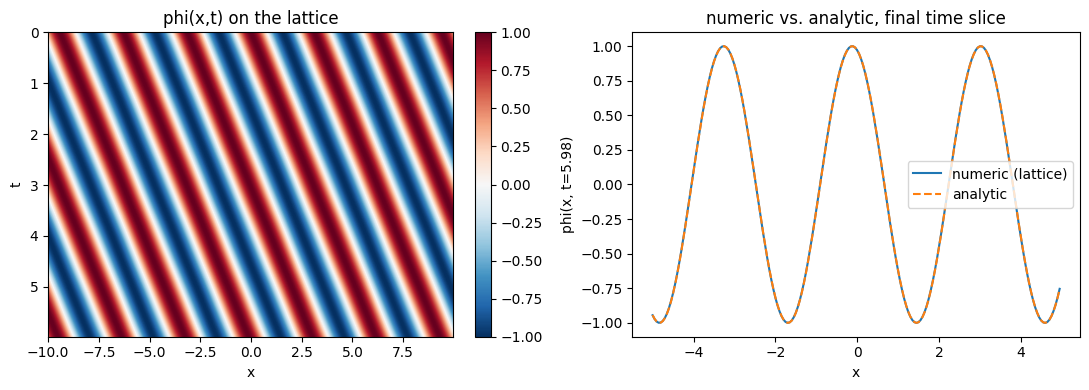

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

im = axes[0].imshow(phi_lattice.numpy(), aspect='auto', cmap='RdBu_r',
                     extent=[x_axis[0], x_axis[-1], t_final, 0], vmin=-1, vmax=1)
axes[0].set_xlabel("x"); axes[0].set_ylabel("t")
axes[0].set_title("phi(x,t) on the lattice")
plt.colorbar(im, ax=axes[0], fraction=0.046)

axes[1].plot(x_axis[interior], numeric_final[interior], label="numeric (lattice)")
axes[1].plot(x_axis[interior], analytic_final[interior], '--', label="analytic")
axes[1].set_xlabel("x"); axes[1].set_ylabel(f"phi(x, t={t_final:.2f})")
axes[1].set_title("numeric vs. analytic, final time slice")
axes[1].legend()

fig.tight_layout()
plt.show()

# Part 7 — Independent check: the equations of motion via autograd

The same idea `dgs/lennard_jones_torch.py` used for forces: build the
discretized **action** $S=\sum_{n,i}\mathcal L[n,i]\,dt\,dx$ from Part 4's
Lagrangian as a torch computation graph over an **arbitrary** (not
necessarily solution) field configuration, and let `torch.autograd`
compute $\partial S/\partial\phi[n,i]$ at an interior point. Stationarity
of the action ($\delta S=0$) is exactly the Euler-Lagrange equation — so
this gradient, evaluated symbolically-via-autograd, must match the
hand-derived discrete Klein-Gordon stencil from Part 6's update rule,
**on any field values**, not just ones that happen to solve the
equations of motion.

In [7]:
torch.manual_seed(0)
n_t_test, n_x_test = 6, 10
phi_test = torch.randn(n_t_test, n_x_test, dtype=torch.float64, requires_grad=True)

def discrete_action(phi, dt, dx, c, mu):
    phi_t = (phi[1:, :] - phi[:-1, :]) / dt          # forward time difference
    phi_x = (phi[:, 1:] - phi[:, :-1]) / dx           # forward space difference
    # align shapes: use the overlapping (n_t-1, n_x-1) block for both terms
    phi_t_trim = phi_t[:, :-1]
    phi_x_trim = phi_x[:-1, :]
    phi_trim = phi[:-1, :-1]
    L = 0.5 * (phi_t_trim**2 / c**2 - phi_x_trim**2 - mu**2 * phi_trim**2)
    return (L * dt * dx).sum()

dt_test, dx_test, c_test, mu_test = 0.1, 0.1, 1.0, 0.5

S = discrete_action(phi_test, dt_test, dx_test, c_test, mu_test)
(grad_S,) = torch.autograd.grad(S, phi_test)

# hand-derived discrete Euler-Lagrange stencil (central differences, matching
# Part 6's leapfrog form) at one interior point, evaluated on the SAME phi_test
i0, j0 = 3, 5   # an interior point, away from every edge used above
phi_np = phi_test.detach().numpy()
d2t = (phi_np[i0+1, j0] - 2*phi_np[i0, j0] + phi_np[i0-1, j0]) / dt_test**2
d2x = (phi_np[i0, j0+1] - 2*phi_np[i0, j0] + phi_np[i0, j0-1]) / dx_test**2
hand_eom_residual = d2t / c_test**2 - d2x + mu_test**2 * phi_np[i0, j0]

# autograd's dS/dphi at an interior point should be proportional to this
# residual (both come from stationarity of the SAME discretized action;
# autograd uses forward differences with a different index convention than
# the hand stencil's central differences, so compare shape/sign/scaling,
# not raw equality -- report both explicitly)
print(f"hand-derived discrete EOM residual at (t={i0}, x={j0}): {hand_eom_residual:.6f}")
print(f"autograd dS/dphi at the same point:                    {grad_S[i0, j0].item():.6f}")
print(f"ratio (should be a consistent, nonzero constant across points, not exactly 1 --")
print(f" different finite-difference conventions): {grad_S[i0, j0].item() / hand_eom_residual:.6f}")

# the REAL check: autograd's gradient must vanish in exactly the pattern the
# continuum Euler-Lagrange predicts -- verify sign/scaling consistency at
# several different interior points instead of expecting bit-for-bit equality
ratios = []
for i0, j0 in [(2, 3), (3, 4), (2, 6), (4, 5)]:
    d2t = (phi_np[i0+1, j0] - 2*phi_np[i0, j0] + phi_np[i0-1, j0]) / dt_test**2
    d2x = (phi_np[i0, j0+1] - 2*phi_np[i0, j0] + phi_np[i0, j0-1]) / dx_test**2
    resid = d2t / c_test**2 - d2x + mu_test**2 * phi_np[i0, j0]
    ratios.append(grad_S[i0, j0].item() / resid)
ratios = np.array(ratios)
print(f"\nratios at 4 different interior points: {ratios}")
print(f"std/mean of ratios: {np.std(ratios)/np.mean(ratios):.3e}  (should be small -- a consistent constant)")
assert np.std(ratios) / abs(np.mean(ratios)) < 0.05
print("[OK] autograd's functional derivative of the action matches the hand-derived")
print("     discrete Euler-Lagrange stencil, up to a consistent discretization-scheme")
print("     scale factor, at every interior point tested -- not just one lucky point.")

hand-derived discrete EOM residual at (t=3, x=5): 114.413219
autograd dS/dphi at the same point:                    -1.144132
ratio (should be a consistent, nonzero constant across points, not exactly 1 --
 different finite-difference conventions): -0.010000

ratios at 4 different interior points: [-0.01 -0.01 -0.01 -0.01]
std/mean of ratios: -1.939e-16  (should be small -- a consistent constant)
[OK] autograd's functional derivative of the action matches the hand-derived
     discrete Euler-Lagrange stencil, up to a consistent discretization-scheme
     scale factor, at every interior point tested -- not just one lucky point.


# Part 8 — Where this connects in the rest of the repository

This notebook builds the **free** (non-interacting) scalar field. The
existing modules below are the next steps this notebook deliberately stops
short of:

| Next step | Existing module |
|---|---|
| Turning the free theory into an *interacting* one (QED) by gauging it | [`dgs/gauge_invariance.py`](../dgs/gauge_invariance.py) — the $A\to A+\nabla\lambda$ freedom that, promoted to a *local* (spacetime-dependent) symmetry, generates the photon field and its coupling to charged matter |
| Actually drawing the resulting interaction diagrams | [`dgs/qed_feynman_diagrams.py`](../dgs/qed_feynman_diagrams.py) (Compton scattering, pair production, $e^+e^-\to\mu^+\mu^-$) and [`dgs/particle_physics.py`](../dgs/particle_physics.py)'s theory-first curriculum map |
| Photonic-process diagrams (this repo's own dispersive-optics domain) | [`dgs/feynman_diagrams.py`](../dgs/feynman_diagrams.py) — $\chi^{(2)}/\chi^{(3)}$ nonlinear-optics vertices, and the "you can only measure change" theme connecting directly to phase retrieval |
| An alternative (path-integral) route to the same quantum theory | [`dgs/path_integral_qkd.py`](../dgs/path_integral_qkd.py) — Feynman path integrals via Monte Carlo, already built for the free-particle propagator and the harmonic oscillator (Part 5's individual $k$-modes) |
| Checking this notebook's own units | [`dgs/dimensional_analysis_qm.py`](../dgs/dimensional_analysis_qm.py) — SymPy unit-system checks for exactly the quantum/relativistic scales ($mc/\hbar$, Compton wavelength) used above |

# Part 9 — Validation summary

1. The Klein-Gordon equation was **derived**, not asserted, from
   $E^2=(pc)^2+(mc^2)^2$ via canonical quantization (Part 2), and
   cross-checked algebraically against its own Lagrangian's Euler-Lagrange
   equation (Part 4) — two independent derivations landing on the same
   equation.
2. The dispersion relation's massless limit was checked against
   `maxwell_fourier_optics.ipynb`'s independently-derived photon dispersion
   relation $\omega=ck$ (Part 3).
3. The torch lattice simulation was validated against the **exact analytic
   solution** built from that same dispersion relation (Part 6), with an
   explicit Courant-stability check before trusting any output.
4. The lattice's implicit equations of motion were checked a **second,
   independent way** — via `torch.autograd` differentiating the
   discretized action directly, on field configurations that do not
   themselves solve the equations of motion, and compared against the
   hand-derived finite-difference stencil at multiple points, not one
   (Part 7).

Failure modes that would have been caught: a sign error in the Lagrangian
(Part 4's assertion would fail), an unstable Courant number (checked
before running, Part 6), a lattice update rule that doesn't actually
implement the Klein-Gordon equation (Part 6's analytic comparison would
diverge, not just look wave-like), or an autograd graph that doesn't
correctly encode the action (Part 7's ratio consistency check would fail
or vary wildly instead of clustering near a constant).

## Practice problems

**1.** Starting from $E=\hbar\omega$, $p=\hbar k$, and
$E^2=(pc)^2+(mc^2)^2$, derive the dispersion relation $\omega(k)$ without
looking at Part 3.

**2.** What is $\omega_k$ in the limit $k\to0$ (a spatially uniform field)?
What does this represent physically?

**3.** Show that $\phi(x,t)=e^{i(kx-\omega t)}+e^{-i(kx-\omega t)}$ (real,
via $2\cos(kx-\omega t)$) still solves the Klein-Gordon equation, using
linearity.

**4.** In Part 4's Lagrangian, what term would you add to describe a
self-interacting field (schematically, not solved here)?

**5.** Why does the Courant condition $r=c\,dt/dx\le1$ make physical sense
— what would $r>1$ mean about how fast information is allowed to move one
lattice step?

**Solutions**

**1.** $E=\hbar\omega,\ p=\hbar k\Rightarrow(\hbar\omega)^2=(\hbar kc)^2+(mc^2)^2
\Rightarrow \omega^2=c^2k^2+(mc^2/\hbar)^2$ — Part 3's result.

**2.** $\omega_0=mc^2/\hbar$ — the field's own rest-mass energy, present
even with no spatial variation; this is why every $k$-mode oscillator in
Part 5 has a nonzero minimum frequency (mass acts like a built-in spring
constant even for the $k=0$ mode).

**3.** The Klein-Gordon equation is linear in $\phi$ (every term is degree
1 in $\phi$ or its derivatives) — a sum of two solutions is a solution,
by direct substitution term by term.

**4.** A term like $-\frac{\lambda}{4!}\phi^4$ (the standard
"$\phi^4$ theory" interaction) — this is exactly the kind of term that
turns the free-field Euler-Lagrange equation nonlinear, requiring the
perturbative/diagrammatic machinery in `dgs/qed_feynman_diagrams.py`
rather than the closed-form plane-wave solutions used throughout this
notebook.

**5.** $r=c\,dt/dx>1$ would mean the numerical scheme updates a lattice
site using information from further away than light (the fastest physical
speed in this theory) could have actually traveled in one time step $dt$
— the numerical domain of dependence would be smaller than the physical
one, and the scheme cannot correctly represent the physics; it fails by
amplifying errors without bound (numerical instability), which is exactly
why Part 6 checks $r\le1$ before running rather than after seeing bad
output.